In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("DATA\Infiltrasjonstester.csv", sep=";")

# Bytt komma til punktum og konverter til tall
for col in df.columns[1:]:
    df[col] = df[col].str.replace(",", ".").astype(float)

df.head()

,Tid i minutter,Rør 1 Københavngata,Rør 2 Københavngata,Rør 3 Københavngata,Rør 1 Deichmans gate,Rør 2 Deichmans gate,Rør 3 Deichmans gate,Rør 1 Maridalsveien,Rør 2 Maridalsveien
0,0,1.5,1.0,1.5,0.0,0.00,0.00,0.0,0.0
1,1,7.0,3.8,6.0,2.5,0.22,0.04,3.7,2.4
2,2,9.5,6.1,10.0,4.0,0.44,0.08,5.7,4.6
3,3,11.0,8.1,13.5,5.7,0.66,0.12,7.5,6.1
4,4,13.0,10.2,16.5,7.0,0.88,0.16,9.0,7.5


In [4]:
df.tail()

,Tid i minutter,Rør 1 Københavngata,Rør 2 Københavngata,Rør 3 Københavngata,Rør 1 Deichmans gate,Rør 2 Deichmans gate,Rør 3 Deichmans gate,Rør 1 Maridalsveien,Rør 2 Maridalsveien
76,76,33.20,21.1,35.0,6.1,4.46,2.56,24.3,28.0
77,77,33.80,21.8,36.0,6.7,4.47,2.57,25.0,28.8
78,78,34.25,22.5,36.6,7.2,4.48,2.58,25.7,29.6
79,79,34.75,23.1,37.1,7.8,4.49,2.59,26.4,30.3
80,80,35.25,23.8,37.5,8.3,4.50,2.60,27.0,31.0


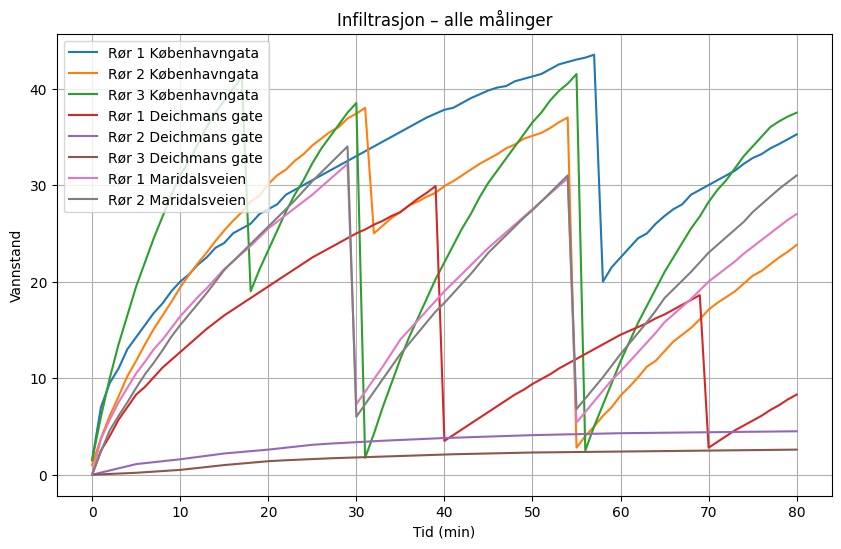

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

for col in df.columns[1:]:
    plt.plot(df["Tid i minutter"], df[col], label=col)

plt.xlabel("Tid (min)")
plt.ylabel("Vannstand")
plt.title("Infiltrasjon – alle målinger")
plt.legend()
plt.grid()
plt.show()

In [6]:
df_hastighet = df.copy()

for col in df.columns[1:]:
    diff = df[col].diff()
    
    # Sett negative verdier til NaN (fjerner reset), for å unngå negative tall.
    # Dette kommer av at vi fyller på vann i trinn, og når det resettes til 0, så blir det en negativ differanse.
    diff[diff < 0] = None
    
    df_hastighet[col] = diff

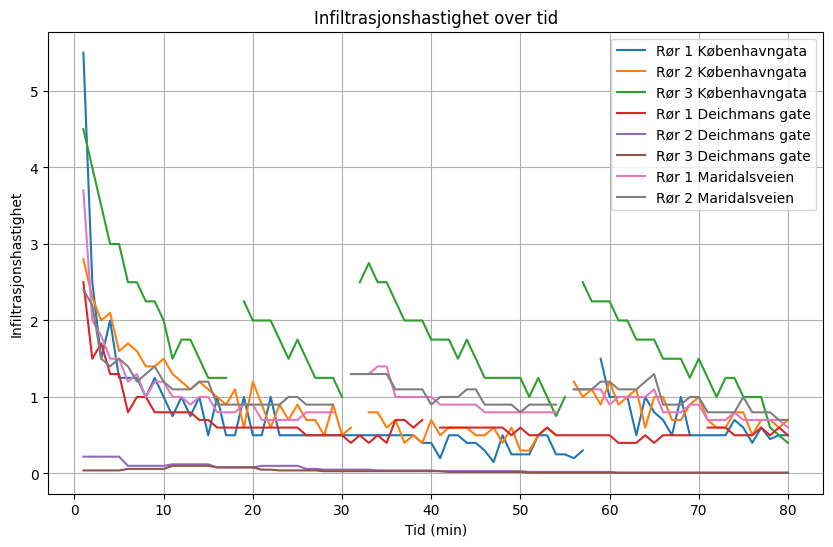

In [7]:
plt.figure(figsize=(10,6))

for col in df_hastighet.columns[1:]:
    plt.plot(df_hastighet["Tid i minutter"], df_hastighet[col], label=col)

plt.xlabel("Tid (min)")
plt.ylabel("Infiltrasjonshastighet")
plt.title("Infiltrasjonshastighet over tid")

plt.legend()
plt.grid()
plt.show()

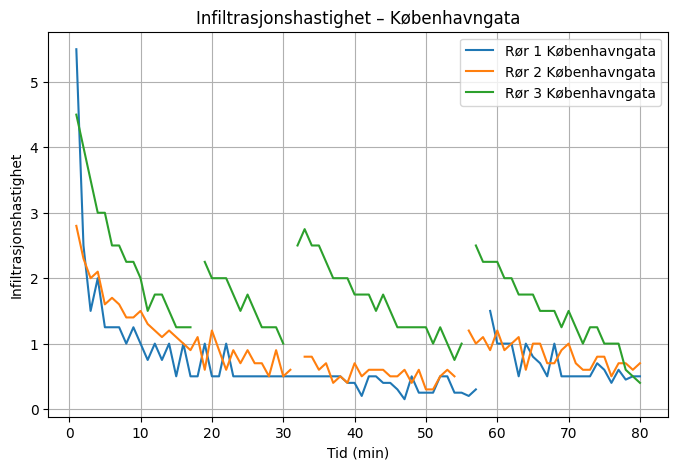

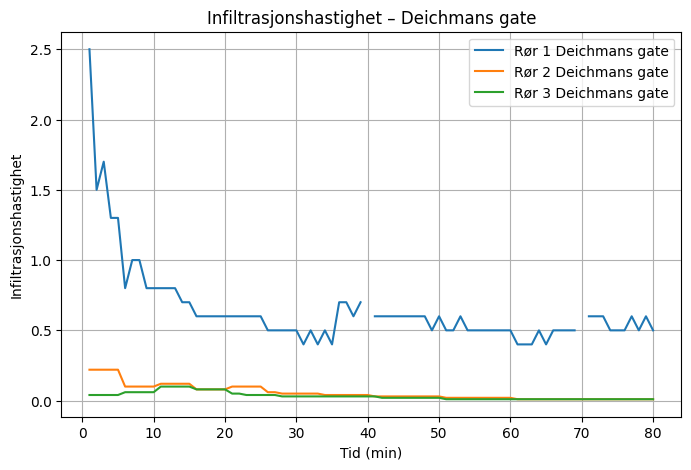

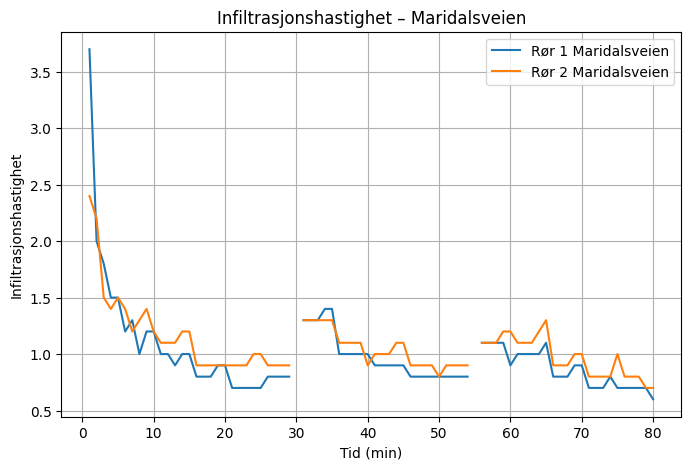

In [8]:
locations = ["Københavngata", "Deichmans gate", "Maridalsveien"]

for loc in locations:
    plt.figure(figsize=(8,5))
    
    cols = [col for col in df_hastighet.columns if loc in col]
    
    for col in cols:
        plt.plot(df_hastighet["Tid i minutter"], df_hastighet[col], label=col)
    
    plt.title(f"Infiltrasjonshastighet – {loc}")
    plt.xlabel("Tid (min)")
    plt.ylabel("Infiltrasjonshastighet")
    plt.legend()
    plt.grid()
    plt.show()

In [9]:
def finn_stabil_hastighet(series):
    # Fjern manglende verdier (NaN) fra dataserien
    s = series.dropna()
    
    # Gå bakover i serien, start nær slutten
    # Vi stopper på index 1 fordi vi ser på grupper av 3 verdier
    for i in range(len(s) - 3, 0, -1):
        
        # Hent ut 3 påfølgende verdier (et lite "vindu")
        subset = s.iloc[i:i+3]
        
        # Sjekk om verdiene er stabile:
        # forskjellen mellom maks og min må være mindre enn
        # 20 % av gjennomsnittet
        if subset.max() - subset.min() < 0.2 * subset.mean():
            
            # Hvis stabilt område er funnet:
            # returner gjennomsnittet som stabil hastighet
            return subset.mean()
    
    # Hvis vi ikke fant noe stabilt område:
    # bruk gjennomsnittet av de siste 5 verdiene som fallback
    return s.tail(5).mean()

In [ ]:
# Finkornig jord (leire): Kₛₐₜ = 0,6 × stabil hastighet
# Grovkornig jord (sand/grus):Kₛₐₜ = 0,8 × stabil hastighet

ksat = {}

for col in df_hastighet.columns[1:]:
    stabil = finn_stabil_hastighet(df_hastighet[col])
    
    # Velg faktor
    if "Københavngata" in col:
        faktor = 0.8 # 50 % mellomsand og 50% siltig mellomsand. 
    elif "Maridalsveien" in col:
        faktor = 0.8 # Pukk 8-12mm med stauder.
    elif "Deichmans gate" in col:
        faktor = 0.8  # 4 % leire, 19 % silt og 77 % sand.
    
    ksat[col] = stabil * faktor

ksat_df = pd.DataFrame.from_dict(ksat, orient="index", columns=["Ksat"])
ksat_df["cm/hr"] = ksat_df["Ksat"] * 60 # Konverter fra cm/min til cm/hr, sidne de er slik de gjør i lærerbøkene
ksat_df

,Ksat,cm/hr
Rør 1 Københavngata,0.386667,23.20
Rør 2 Københavngata,0.533333,32.00
Rør 3 Københavngata,0.800000,48.00
Rør 1 Deichmans gate,0.426667,25.60
Rør 2 Deichmans gate,0.008000,0.48
Rør 3 Deichmans gate,0.008000,0.48
Rør 1 Maridalsveien,0.533333,32.00
Rør 2 Maridalsveien,0.586667,35.20


In [15]:
import pandas as pd
import numpy as np
from scipy import stats

resultater = []

for col in df_hastighet.columns[1:]:
    data = df_hastighet[col].dropna()
    
    mean = data.mean()
    std = data.std()
    n = len(data)
    
    # 95% konfidensintervall (t-fordeling)
    ci_low, ci_high = stats.t.interval(
        0.95, df=n-1, loc=mean, scale=std/np.sqrt(n)
    )
    
    resultater.append({
        "Rør": col,
        "Mean": mean,
        "Std": std,
        "N": n,
        "CI_lower": ci_low,
        "CI_upper": ci_high
    })

df_stats = pd.DataFrame(resultater)

In [14]:
stabilitet_resultater = []

for col in df_hastighet.columns[1:]:
    data = df_hastighet[col].dropna()
    
    siste = data.tail(5)
    
    mean = siste.mean()
    max_val = siste.max()
    min_val = siste.min()
    
    # prosentvis variasjon
    variation_percent = (max_val - min_val) / mean * 100
    
    stabil = variation_percent <= 20
    
    stabilitet_resultater.append({
        "Rør": col,
        "Mean_last5": mean,
        "Max": max_val,
        "Min": min_val,
        "Variation_%": variation_percent,
        "Stabil (Ksat)": stabil
    })

df_stabilitet = pd.DataFrame(stabilitet_resultater)

In [16]:
df_final = pd.merge(df_stats, df_stabilitet, on="Rør")
df_final

,Rør,Mean,Std,N,CI_lower,CI_upper,Mean_last5,Max,Min,Variation_%,Stabil (Ksat)
0,Rør 1 Københavngata,0.724684,0.675338,79,0.573416,0.875951,0.49,0.60,0.40,4.081633e+01,False
1,Rør 2 Københavngata,0.897436,0.458958,78,0.793957,1.000915,0.64,0.70,0.50,3.125000e+01,False
2,Rør 3 Københavngata,1.740260,0.728419,77,1.574929,1.905591,0.70,1.00,0.40,8.571429e+01,False
3,Rør 1 Deichmans gate,0.647436,0.314054,78,0.576628,0.718244,0.54,0.60,0.50,1.851852e+01,True
4,Rør 2 Deichmans gate,0.056250,0.055264,80,0.043952,0.068548,0.01,0.01,0.01,8.881784e-12,True
5,Rør 3 Deichmans gate,0.032500,0.026553,80,0.026591,0.038409,0.01,0.01,0.01,4.440892e-12,True
6,Rør 1 Maridalsveien,0.989744,0.403102,78,0.898858,1.080629,0.68,0.70,0.60,1.470588e+01,True
7,Rør 2 Maridalsveien,1.066667,0.275241,78,1.004609,1.128724,0.76,0.80,0.70,1.315789e+01,True


Tolkning av statistiske resultater og stabilitet (Ksat):

Tabellen viser tydelige forskjeller i infiltrasjonsevne mellom de undersøkte lokalitetene. Deichmans gate har svært lave gjennomsnittsverdier, med 0.056 og 0.033 for rør 2 og 3, og tilsvarende smale konfidensintervaller (f.eks. 0.044–0.069). Dette indikerer lav infiltrasjonskapasitet. I kontrast viser Københavngata betydelig høyere verdier, fra 0.725 (rør 1) til 1.740 (rør 3), samtidig som standardavviket er høyt (opptil 0.728), noe som tyder på stor intern variasjon. Maridalsveien har gjennomsnittsverdier på henholdsvis 0.990 og 1.067, med moderate standardavvik (0.403 og 0.275), noe som indikerer relativt gode og mer stabile infiltrasjonsforhold.

Vurderingen av mettet hydraulisk konduktivitet (Ksat) basert på de siste målingene viser at stabil tilstand (±20 %) er oppnådd for Deichmans gate og Maridalsveien. For eksempel har rør 1 ved Deichmans gate en variasjon på 18.5 %, mens rør 2 og 3 har tilnærmet null variasjon (~0 %). Tilsvarende ligger Maridalsveien på henholdsvis 14.7 % og 13.2 %, som er godt innenfor stabilitetskriteriet.

For Københavngata overstiger variasjonen derimot stabilitetskriteriet i alle rør, med 40.8 % (rør 1), 31.3 % (rør 2) og hele 85.7 % (rør 3). Dette viser at infiltrasjonshastigheten fortsatt var i en avtakende fase og at metning ikke var oppnådd. De beregnede infiltrasjonsverdiene for Københavngata representerer derfor ikke nødvendigvis reell Ksat, og kan være overestimert.

Samlet sett viser resultatene at Deichmans gate består av lavpermeable masser som raskt oppnår stabil infiltrasjon, mens Maridalsveien har høyere og stabile infiltrasjonsrater. Københavngata skiller seg ut med både høyere infiltrasjon og stor variasjon, samt manglende stabilisering, noe som indikerer mer heterogene og permeable masser som krever lengre tid for å oppnå mettet tilstand.

In [17]:
import itertools
from scipy.stats import ttest_ind

resultater_ttest = []

# Fjern "Tid i minutter"
kolonner = [col for col in df_hastighet.columns if col != "Tid i minutter"]

# Lag alle kombinasjoner av rør
for r1, r2 in itertools.combinations(kolonner, 2):
    
    data1 = df_hastighet[r1].dropna()
    data2 = df_hastighet[r2].dropna()
    
    # Welch’s t-test (ulik varians)
    t_stat, p_val = ttest_ind(data1, data2, equal_var=False)
    
    resultater_ttest.append({
        "Rør 1": r1,
        "Rør 2": r2,
        "t-verdi": t_stat,
        "p-verdi": p_val,
        "Signifikant (<0.05)": p_val < 0.05
    })

df_ttest = pd.DataFrame(resultater_ttest)
df_ttest.sort_values("p-verdi")

,Rør 1,Rør 2,t-verdi,p-verdi,Signifikant (<0.05)
24,Rør 2 Deichmans gate,Rør 2 Maridalsveien,-31.802624,2.861437e-48,True
26,Rør 3 Deichmans gate,Rør 2 Maridalsveien,-33.034159,9.085927e-48,True
25,Rør 3 Deichmans gate,Rør 1 Maridalsveien,-20.928524,1.166956e-33,True
23,Rør 2 Deichmans gate,Rør 1 Maridalsveien,-20.267531,3.260235e-33,True
15,Rør 3 Københavngata,Rør 3 Deichmans gate,20.559528,8.019761e-33,True
14,Rør 3 Københavngata,Rør 2 Deichmans gate,20.230602,1.634047e-32,True
19,Rør 1 Deichmans gate,Rør 3 Deichmans gate,17.233165,2.491443e-28,True
18,Rør 1 Deichmans gate,Rør 2 Deichmans gate,16.379799,1.577156e-27,True
10,Rør 2 Københavngata,Rør 3 Deichmans gate,16.616920,2.898738e-27,True
9,Rør 2 Københavngata,Rør 2 Deichmans gate,16.073774,1.195672e-26,True


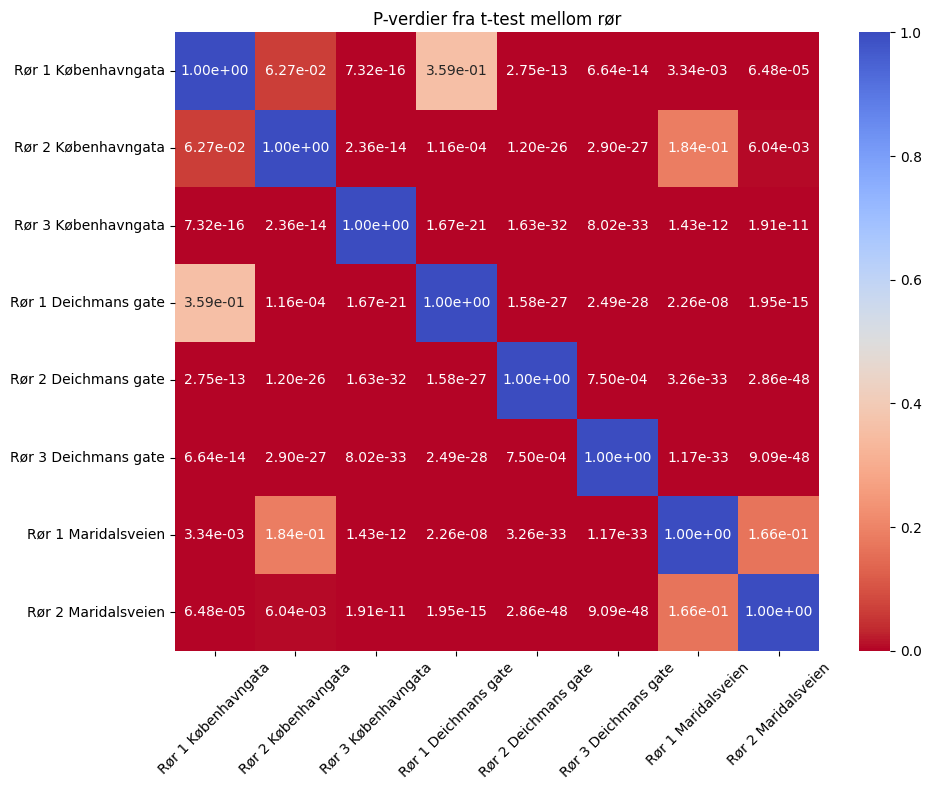

In [18]:
import seaborn as sns

# Lag liste over rør (uten tid)
kolonner = [col for col in df_hastighet.columns if col != "Tid i minutter"]

# Lag tom matrise
p_matrix = pd.DataFrame(index=kolonner, columns=kolonner, dtype=float)

from scipy.stats import ttest_ind

# Fyll inn p-verdier
for r1 in kolonner:
    for r2 in kolonner:
        if r1 == r2:
            p_matrix.loc[r1, r2] = 1
        else:
            data1 = df_hastighet[r1].dropna()
            data2 = df_hastighet[r2].dropna()
            _, p_val = ttest_ind(data1, data2, equal_var=False)
            p_matrix.loc[r1, r2] = p_val

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(p_matrix.astype(float), annot=True, fmt=".2e", cmap="coolwarm_r")

plt.title("P-verdier fra t-test mellom rør")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Tolkning av T-test

De parvise t-testene viser at infiltrasjonsevnen ved Deichmans gate er signifikant lavere enn ved de øvrige lokalitetene (p << 0.05 i alle sammenligninger). Dette indikerer at forskjellene ikke skyldes tilfeldig variasjon, men reelle forskjeller i jordas egenskaper.

Sammenligningen mellom Københavngata og Maridalsveien gir både signifikante og ikke-signifikante resultater (p > 0.05 i enkelte tilfeller), noe som tyder på delvis overlappende infiltrasjonsegenskaper.

Innenfor samme lokalitet er det i flere tilfeller ikke signifikante forskjeller mellom rør, noe som styrker påliteligheten til målingene og indikerer relativt homogene forhold innen hvert område.

T-testene bekrefter dermed at Deichmans gate skiller seg tydelig ut som et område med lav infiltrasjonsevne, mens de øvrige lokalitetene har mer sammenlignbare egenskaper.

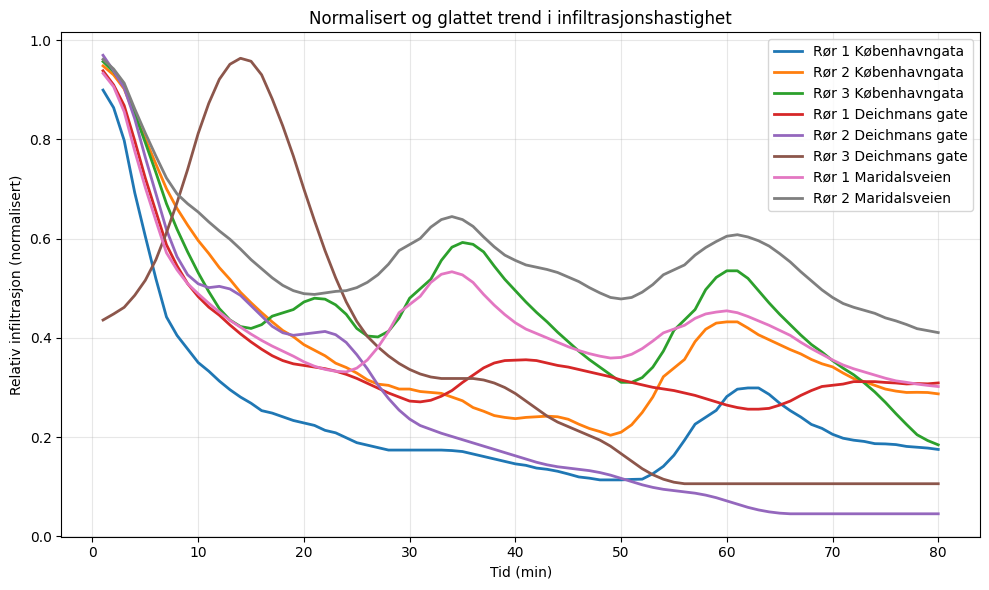

In [19]:
plt.figure(figsize=(10, 6))

for col in df_hastighet.columns:
    if col != "Tid i minutter":
        data = df_hastighet[col].dropna()
        t = df_hastighet.loc[data.index, "Tid i minutter"]
        
        # Hopp over hvis første verdi er 0
        if data.iloc[0] == 0:
            continue
        
        # 🔹 1. Glatt først (viktig!)
        data_smooth = data.rolling(window=7, center=True, min_periods=1).mean()
        
        # 🔹 2. Normaliser etter glatting (mer stabilt)
        norm = data_smooth / data_smooth.max()
        
        # 🔹 3. Ekstra lett glatting (valgfritt, gir veldig fine kurver)
        norm_smooth = norm.rolling(window=5, center=True, min_periods=1).mean()
        
        plt.plot(t, norm_smooth, linewidth=2, label=col)

plt.xlabel("Tid (min)")
plt.ylabel("Relativ infiltrasjon (normalisert)")
plt.title("Normalisert og glattet trend i infiltrasjonshastighet")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import linregress

trend_resultater = []

for col in df_hastighet.columns:
    if col != "Tid i minutter":
        data = df_hastighet[col].dropna()
        t = df_hastighet.loc[data.index, "Tid i minutter"]
        
        slope, intercept, r_value, p_value, std_err = linregress(t, data)
        
        trend_resultater.append({
            "Rør": col,
            "Helning": slope,
            "R²": r_value**2,
            "p-verdi": p_value
        })

df_trend = pd.DataFrame(trend_resultater)
df_trend

,Rør,Helning,R²,p-verdi
0,Rør 1 Københavngata,-0.011811,0.166068,1.933807e-04
1,Rør 2 Københavngata,-0.010862,0.308279,1.322210e-07
2,Rør 3 Københavngata,-0.018261,0.345818,1.871292e-08
3,Rør 1 Deichmans gate,-0.007666,0.323289,5.618981e-08
4,Rør 2 Deichmans gate,-0.002037,0.733848,3.979121e-24
5,Rør 3 Deichmans gate,-0.000915,0.641093,4.924304e-19
6,Rør 1 Maridalsveien,-0.007880,0.210134,2.437739e-05
7,Rør 2 Maridalsveien,-0.006309,0.288932,3.886381e-07


Sammenheng mellom trendanalyse og graf

Trendanalysen viser at alle målepunktene har en negativ helning, noe som bekrefter at infiltrasjonshastigheten avtar over tid. Dette samsvarer med den visuelle utviklingen i figur X, hvor kurvene faller før de stabiliserer seg.

Københavngata har de største negative helningene (ned til -0.018), noe som indikerer en rask reduksjon i infiltrasjonshastighet. Dette stemmer med grafen, hvor kurvene viser et tydelig og vedvarende fall uten stabilisering. Den lave forklaringsgraden (R² = 0.17–0.35) tyder også på større variasjon i målingene, noe som kan forklares med heterogene jordforhold.

For Deichmans gate er helningene nær null (ned til -0.0009), og R²-verdiene er høye (opptil 0.73). Dette indikerer stabile og lite varierende forhold, noe som også observeres i grafen der kurvene flater raskt ut. Dette er konsistent med lav infiltrasjonskapasitet og rask oppnåelse av mettet tilstand.

Maridalsveien har moderate helninger (-0.006 til -0.008) og middels R²-verdier, noe som indikerer en gradvis reduksjon i infiltrasjon før stabilisering. Dette samsvarer med grafen, hvor kurvene viser en jevn overgang til stabil tilstand.

Samlet sett viser trendanalysen god samsvar med den visuelle utviklingen i infiltrasjonskurvene, og gir en kvantitativ bekreftelse på forskjellene mellom lokalitetene.